# Models for Real News

## Imports

In [1]:
# reading df
import pandas as pd

# Model Libs
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from joblib import dump
import warnings

We have introduced this line of code since when training the logistic regersion we get a future warning which can be ignored.

In [2]:
warnings.filterwarnings("ignore")

## Introduction

In this notebook we will prepare the data (vectorize it and split it) to fit into several models. These models include a logistic regression, random forest and SVM.

## Prep data

In [3]:
df = pd.read_csv("DF_final.csv")

x_train, x_test, y_train, y_test = train_test_split(
    df["text_clean"], df["label"], 
    test_size = 0.3, random_state = 42, 
    stratify = df["label"])


In [4]:
# Vecotrizing
vect = TfidfVectorizer(
    max_features = 1000,
    min_df = 10,
    ngram_range = (1, 3)
)

x_train_vec = vect.fit_transform(x_train)
x_test_vec = vect.transform(x_test)

In [5]:
dump(vect, "vectorizer_rn.joblib")

['vectorizer_rn.joblib']

## Model 1: Logistic Regression

First we tried a logistic regession with minimal tuning.

In [6]:
log_reg = LogisticRegression(solver = "liblinear", random_state = 42)
log_reg.fit(x_train_vec, y_train)
pred_log = log_reg.predict(x_test_vec)

print(f"Accuracy: {accuracy_score(y_test, pred_log)}")
print(classification_report(y_test, pred_log))

Accuracy: 0.9642584097859327
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      5232
           1       0.96      0.97      0.96      5232

    accuracy                           0.96     10464
   macro avg       0.96      0.96      0.96     10464
weighted avg       0.96      0.96      0.96     10464



All of the results of the metrics are good. We obtained an acuracy of 96% with similar precision recall and f1-score between classes and a macro/weighted avg of equal value (0.96).

Text(70.72222222222221, 0.5, 'Actual Label')

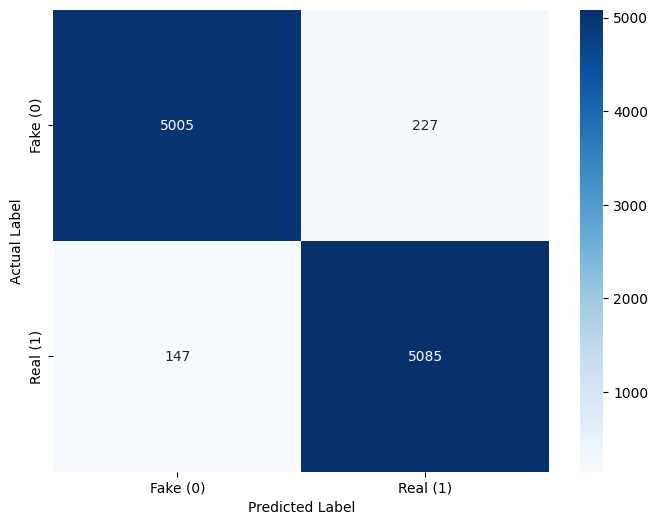

In [7]:
cm = confusion_matrix(y_test, pred_log)

plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues",
            xticklabels = ["Fake (0)", "Real (1)"],
            yticklabels = ["Fake (0)", "Real (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
            

In [8]:
# To check if overfitting occurs
train_acc = log_reg.score(x_train_vec, y_train)
test_acc = log_reg.score(x_test_vec, y_test)

print(f"Train acc: {train_acc}")
print(f"Test acc: {test_acc}")

Train acc: 0.9720265399737876
Test acc: 0.9642584097859327


As we see above the training accuracy and the test accuracy are very close to each other indicating there is no sign of overfitting. However, though the first attempt was successful we wanted to apply a grid search to try and optimize the results even  further.

In [9]:
def run_grid_search(model, params):
    mod = None
    if model == "Log reg":
        mod = LogisticRegression(random_state = 42)
    elif model == "Rand for class":
        mod = RandomForestClassifier(random_state = 42)
    else:
        mod = LinearSVC(dual = False, random_state = 42)
        model = "SVC"

    grid_search = GridSearchCV(
        estimator = mod,
        param_grid = params,
        cv = 5,
        scoring = "accuracy",
        n_jobs = -1)

    grid_search.fit(x_train_vec, y_train)

    best_mod = grid_search.best_estimator_

    y_pred = best_mod.predict(x_test_vec)

    train_acc = best_mod.score(x_train_vec, y_train)
    test_acc = best_mod.score(x_test_vec, y_test)

    print(f" - Results for {model} -")
    print(f"Best Params: {grid_search.best_params_}")
    print(f"Final Test Acc: {round(test_acc, 2)}")
    print(f"Final Train Acc: {round(train_acc, 2)}")
    print(f"\n Classification Report:")
    print(classification_report(y_test, y_pred))
   
    
    return best_mod
    

In [10]:
parameters_grid_log = [{"solver": ["liblinear", "saga"],
                    "penalty": ["l1", "l2"],
                    "C": [0.1, 1, 3, 6, 10],
                    "max_iter": [100, 500, 1000]}, 
                   {"solver": ["lbfgs", "newton-cg"],
                    "penalty": ["l2"],
                    "C": [0.1, 1, 3, 6, 10],
                    "max_iter": [100, 500, 1000]}]
results_log_reg = run_grid_search("Log reg", parameters_grid_log)

 - Results for Log reg -
Best Params: {'C': 3, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Final Test Acc: 0.97
Final Train Acc: 0.98

 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      5232
           1       0.96      0.97      0.97      5232

    accuracy                           0.97     10464
   macro avg       0.97      0.97      0.97     10464
weighted avg       0.97      0.97      0.97     10464



If we compare the results one can observe that we achieve a higher training and test accuracy with a small difference, hence no overfitting. The accuracy as also increased a little bit to 0.97. In addition, most of the values in the classification report have increased except for the recall of the fake news (class 0) and the presion of real news (class 1). 

In [11]:
dump(results_log_reg, "log_reg_rn.joblib")

['log_reg_rn.joblib']

## Model 2: Random Forest

Another model we wanted to try was random forest as it is robust to overfitting and it generally performs better than a decision tree. Given the function created previously for grid serach we have directly implemented it rather than testing a combination of parameters.

In [12]:
parameters_grid_rand = {"n_estimators": [100, 200],
                        "max_depth": [10, 12, 14],
                        "min_samples_leaf": [5, 10, 20],
                        "min_samples_split": [15, 20, 25],
                        "bootstrap" : [True]}
results_rand = run_grid_search("Rand for class", parameters_grid_rand)

 - Results for Rand for class -
Best Params: {'bootstrap': True, 'max_depth': 14, 'min_samples_leaf': 5, 'min_samples_split': 25, 'n_estimators': 200}
Final Test Acc: 0.95
Final Train Acc: 0.97

 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      5232
           1       0.94      0.96      0.95      5232

    accuracy                           0.95     10464
   macro avg       0.95      0.95      0.95     10464
weighted avg       0.95      0.95      0.95     10464



One can observe that there is a slightly larger gap between the training and testing accuracy. However, given the difference between the training and testing is not larger than 5% then there is no need to worry [[source]](https://www.kaggle.com/discussions/questions-and-answers/192391). In addition, it has a lower training and testing accuracy than the logistic regression indicating it performs slightly worse. However, given the accuracy is of the random forest is 0.95 the model itself is good. One can observe that the logistic regression perform slightly better due that the classification report of the random forest having lower values for the different metrics and types (i.e. macro avg and weighted avg) the logistic regression performed better.

In [13]:
dump(results_rand, "rand_for_rn.joblib")

['rand_for_rn.joblib']

# Model 3: SVC (SVM)

In [14]:
parameters_grid_svc = {"C": [0.1, 1, 3, 6, 10],
                       "max_iter": [2500],
                      "class_weight":["balanced"]} 
results_svc = run_grid_search("SVC", parameters_grid_svc)

 - Results for SVC -
Best Params: {'C': 1, 'class_weight': 'balanced', 'max_iter': 2500}
Final Test Acc: 0.97
Final Train Acc: 0.98

 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      5232
           1       0.96      0.97      0.97      5232

    accuracy                           0.97     10464
   macro avg       0.97      0.97      0.97     10464
weighted avg       0.97      0.97      0.97     10464



The SVM was able to achieve the same results as for the logistic regression. The classification report is identical as well as the test and training accuracy. 

In [15]:
dump(results_svc, "svc_rn.joblib")

['svc_rn.joblib']